In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!yolo segment train model=yolov8n-seg.pt data="/content/drive/MyDrive/LaneDetection-Segmentation-.v1i.yolov8/data.yaml" epochs=5 imgsz=640

In [ ]:
# Cài đặt và chuẩn bị môi trường
!pip install ultralytics -q
from ultralytics import YOLO
import os, shutil, glob

#  Copy dataset từ Drive sang /content (đọc nhanh hơn Drive)
if not os.path.exists("/content/LaneDetection-Segmentation-.v1i.yolov8"):
    !cp -r "/content/drive/MyDrive/LaneDetection-Segmentation-.v1i.yolov8" /content/



#  TRAIN — tất cả tùy chọn đã tối ưu tốc độ
!yolo segment train model="/content/drive/MyDrive/yolov8_models/lane_seg_best.pt" \
    data="/content/LaneDetection-Segmentation-.v1i.yolov8/data.yaml" \
    epochs=40 imgsz=480 batch=-1 cache=True device=0 workers=4 \
    project="/content/runs/segment" name="train_fast" exist_ok=True \
    save_period=0 verbose=False augment=False optimizer=SGD

#  LƯU MÔ HÌNH MỚI NHẤT VÀO DRIVE
latest_run = max(glob.glob("/content/runs/segment/train*"), key=os.path.getctime)
save_dir = "/content/drive/MyDrive/yolov8_models"
os.makedirs(save_dir, exist_ok=True)
shutil.copy(f"{latest_run}/weights/best.pt", f"{save_dir}/lane_seg_best_fast.pt")

print(f" Huấn luyện hoàn tất! Mô hình đã lưu vào: {save_dir}/lane_seg_best_fast.pt")

Ultralytics 8.3.221 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/LaneDetection-Segmentation-.v1i.yolov8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=480, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/yolov8_models/lane_seg_best.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train_fast, nbs=64, nms=False, opset=None, optimize=False, optimizer=SG

In [ ]:
# 1. Cài đặt môi trường
!pip install ultralytics -q
from ultralytics import YOLO
import os, shutil, glob

# 2. Copy dataset từ Drive sang /content (đọc nhanh hơn Drive)
if not os.path.exists("/content/LaneDetection-Segmentation-.v1i.yolov8"):
    !cp -r "/content/drive/MyDrive/LaneDetection-Segmentation-.v1i.yolov8" /content/


# 3. Resume training từ checkpoint cũ
old_checkpoint = "/content/drive/MyDrive/yolov8_models/lane_seg_best_fast.pt"

!yolo segment train \
    model="{old_checkpoint}" \
    data="/content/LaneDetection-Segmentation-.v1i.yolov8/data.yaml" \
    epochs=5 imgsz=480 batch=-1 cache=True device=0 workers=4 \
    project="/content/runs/segment" name="train_resume" exist_ok=True \
    save_period=0 verbose=False optimizer=SGD

# 4. Lưu mô hình mới nhất vào Drive
latest_run = max(glob.glob("/content/runs/segment/train_resume*"), key=os.path.getctime)
save_dir = "/content/drive/MyDrive/yolov8_models"
os.makedirs(save_dir, exist_ok=True)
shutil.copy(f"{latest_run}/weights/best.pt", f"{save_dir}/lane_seg_best_resume.pt")

print(f"Huấn luyện tiếp tục hoàn tất. Mô hình mới đã lưu vào: {save_dir}/lane_seg_best_resume.pt")


Ultralytics 8.3.221 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/LaneDetection-Segmentation-.v1i.yolov8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=480, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/yolov8_models/lane_seg_best_fast.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train_resume, nbs=64, nms=False, opset=None, optimize=False, optimi

In [ ]:
# 1. Cài đặt môi trường
!pip install ultralytics -q
from ultralytics import YOLO
import os, shutil, glob

# 2. Copy dataset từ Drive sang /content (đọc nhanh hơn Drive)
if not os.path.exists("/content/LaneDetection-Segmentation-.v1i.yolov8"):
    !cp -r "/content/drive/MyDrive/LaneDetection-Segmentation-.v1i.yolov8" /content/


# 3. Resume training từ checkpoint cũ
old_checkpoint = "/content/drive/MyDrive/yolov8_models/lane_seg_best_resume.pt"

!yolo segment train \
    model="{old_checkpoint}" \
    data="/content/LaneDetection-Segmentation-.v1i.yolov8/data.yaml" \
    epochs=3 imgsz=480 batch=-1 cache=True device=0 workers=4 \
    project="/content/runs/segment" name="train_resume" exist_ok=True \
    save_period=0 verbose=False optimizer=SGD

# 4. Lưu mô hình mới nhất vào Drive
latest_run = max(glob.glob("/content/runs/segment/train_resume*"), key=os.path.getctime)
save_dir = "/content/drive/MyDrive/yolov8_models"
os.makedirs(save_dir, exist_ok=True)
shutil.copy(f"{latest_run}/weights/best.pt", f"{save_dir}/lane_seg_best_resume.pt")

print(f"Huấn luyện tiếp tục hoàn tất. Mô hình mới đã lưu vào: {save_dir}/lane_seg_best_resume.pt")


Ultralytics 8.3.221 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/LaneDetection-Segmentation-.v1i.yolov8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=3, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=480, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/yolov8_models/lane_seg_best_resume.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train_resume, nbs=64, nms=False, opset=None, optimize=False, opti

In [ ]:
from ultralytics import YOLO
import shutil, glob, os
from IPython.display import HTML
from base64 import b64encode

# Nạp mô hình vừa train xong
model = YOLO("/content/drive/MyDrive/yolov8_models/lane_seg_best_fast.pt")

# Đặt đường dẫn video test
video_path = "/content/Video_Test_New.mp4"   # thay bằng video của bạn

# Thư mục lưu kết quả
save_dir = "/content/runs/segment/predict_video"
os.makedirs(save_dir, exist_ok=True)

# Chạy dự đoán
results = model.predict(
    source=video_path,
    save=True,               # lưu video kết quả
    project="/content/runs/segment",
    name="predict_video",
    conf=0.5,                # ngưỡng tin cậy
    imgsz=480,
    show=False,              # không cần hiển thị realtime
    show_labels=False,       # ẩn chữ nhãn (Right Boundary, Left Boundary...)
    show_conf=False          # ẩn độ tin cậy (0.98, 0.64...)
)



WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/1734) /content/Video_Test_New.mp4: 288x480 1 Left Boundary -Solid-, 2 Right Boundary -Solid-s, 48.9ms
video 1/1 (frame 2/1734) /content/Video_Test_New.mp4: 288x480 1 Left Boundary -Solid-, 2 Right Boundary -Solid-s, 7.0ms
video 1/1 (frame 3/1734) /content/Video_Test_New.mp4: 288x480 1 Left Boundary -Solid-, 2 Right Boundary -Solid-s, 6.3ms
video 1/1 (frame 4/1734) /content/Video_Test_New.mp4: 288x480 1 Left Boundary -Solid-, 2 Right 

In [ ]:
!nvidia-smi

Tue Oct 21 12:37:05 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import pandas as pd

log_path = "/content/runs/segment/train_fast/results.csv"
df = pd.read_csv(log_path)

# Hiển thị 5 dòng đầu tiên
df.head()

,epoch,time,train/box_loss,train/seg_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),...,metrics/recall(M),metrics/mAP50(M),metrics/mAP50-95(M),val/box_loss,val/seg_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,33.1352,0.74672,0.76707,1.06271,0.88256,0.60053,0.77178,0.71097,0.54535,...,0.74397,0.68703,0.39138,0.86161,0.85271,1.01595,0.88834,0.077500,0.002500,0.002500
1,2,64.0531,0.76418,0.77019,0.97913,0.88092,0.63264,0.72608,0.70187,0.53801,...,0.71244,0.69485,0.39594,0.85042,0.84015,1.00480,0.88900,0.053974,0.004974,0.004974
2,3,95.7708,0.83223,0.81265,0.99431,0.90029,0.41990,0.46522,0.40405,0.27577,...,0.44660,0.37974,0.17484,1.31582,1.50115,1.89804,1.10779,0.030319,0.007319,0.007319
3,4,125.9230,0.88001,0.82910,1.04800,0.91330,0.32970,0.52829,0.41447,0.26683,...,0.49180,0.37487,0.17289,1.23024,1.27560,1.67038,1.01866,0.009258,0.009258,0.009258
4,5,157.3580,0.90306,0.85995,1.08350,0.91943,0.44412,0.62020,0.50956,0.33916,...,0.60081,0.49178,0.23659,1.17152,1.12922,1.57913,1.01264,0.009010,0.009010,0.009010


In [ ]:
!yolo val model=/content/runs/segment/train_fast/weights/best.pt \
    data=/content/LaneDetection-Segmentation-.v1i.yolov8/data.yaml \
    split=val save_json save_txt


Ultralytics 8.3.219 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n-seg summary (fused): 85 layers, 3,258,844 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1366.3±585.5 MB/s, size: 62.9 KB)
val: Scanning /content/LaneDetection-Segmentation-.v1i.yolov8/valid/labels.cache... 318 images, 21 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 318/318 4.3Mit/s 0.0s
requirements: Ultralytics requirement ['faster-coco-eval>=1.6.7'] not found, attempting AutoUpdate...

requirements: AutoUpdate success ✅ 0.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 0.5it/s 38.6s
                   all        318        853      0.878      0.829      0.893      0.709      0.862      0.792       0.85      0.386
Left Boundary -Dashed-        158        363     

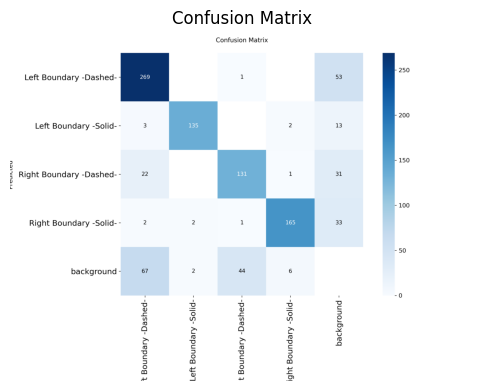

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Đường dẫn tới file confusion matrix
img_path = "/content/runs/segment/train_fast/confusion_matrix.png"

# Đọc và hiển thị
img = mpimg.imread(img_path)
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
import pandas as pd

# Đường dẫn đến file kết quả YOLO
log_path = "/content/runs/segment/train_fast/results.csv"

# Đọc file CSV vào DataFrame
df = pd.read_csv(log_path)

# In danh sách cột có trong file
print(df.columns.tolist())

['epoch', 'time', 'train/box_loss', 'train/seg_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'metrics/precision(M)', 'metrics/recall(M)', 'metrics/mAP50(M)', 'metrics/mAP50-95(M)', 'val/box_loss', 'val/seg_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


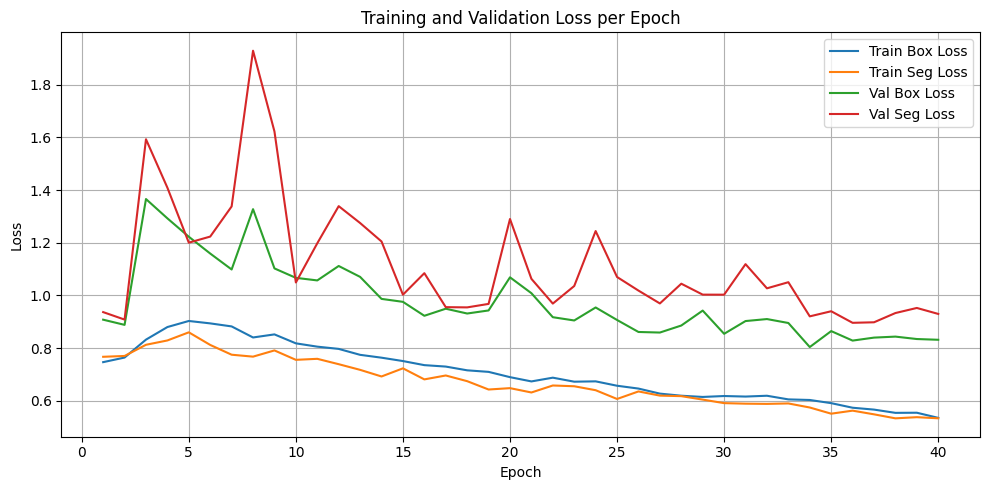

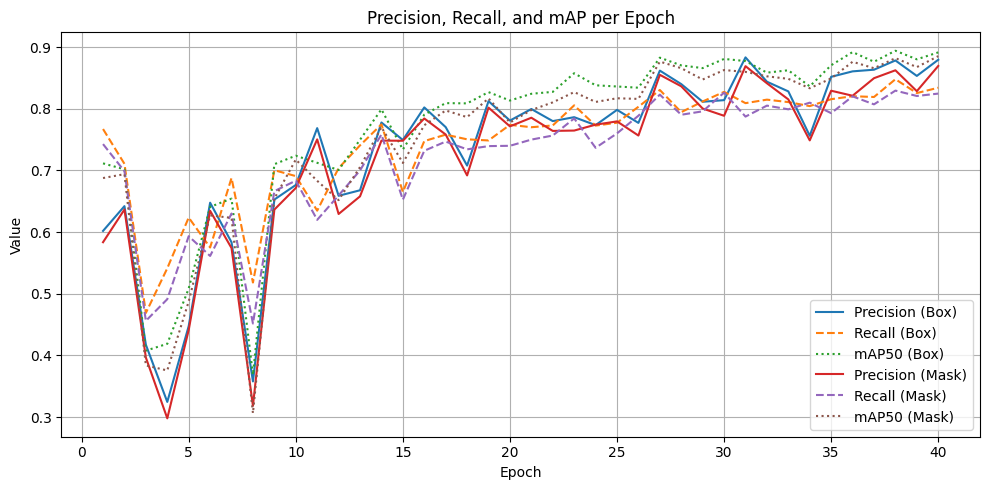

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Đọc file kết quả
log_path = "/content/runs/segment/train_fast/results.csv"
df = pd.read_csv(log_path)

# Biểu đồ 1: Loss
plt.figure(figsize=(10,5))
plt.plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
plt.plot(df['epoch'], df['train/seg_loss'], label='Train Seg Loss')
plt.plot(df['epoch'], df['val/box_loss'], label='Val Box Loss')
plt.plot(df['epoch'], df['val/seg_loss'], label='Val Seg Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss per Epoch')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Biểu đồ 2: Precision, Recall, mAP
plt.figure(figsize=(10,5))
plt.plot(df['epoch'], df['metrics/precision(B)'], label='Precision (Box)', linestyle='-')
plt.plot(df['epoch'], df['metrics/recall(B)'], label='Recall (Box)', linestyle='--')
plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50 (Box)', linestyle=':')
plt.plot(df['epoch'], df['metrics/precision(M)'], label='Precision (Mask)', linestyle='-')
plt.plot(df['epoch'], df['metrics/recall(M)'], label='Recall (Mask)', linestyle='--')
plt.plot(df['epoch'], df['metrics/mAP50(M)'], label='mAP50 (Mask)', linestyle=':')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Precision, Recall, and mAP per Epoch')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()